In [ ]:
import pickle as pkl

import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import numpy as np
norm_dict = {"max":max,"min":min,"None":lambda x:1}



In [ ]:
import pickle as pkl

import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import numpy as np
norm_dict = {"max":max,"min":min,"None":lambda x:1}



### Open the saved distances

In [ ]:
with open("FILE/PATH.lT", "rb") as f:
    file = pkl.load(f)

### Add the parameters

In [ ]:
time = 0
normalization= "max"

In [ ]:
def plot_clustermap(file,time,normalization):
    comparisons = file["comparisons"]
    names = file["names"]
    norms = file["norms"]
    len_all_trees = len(names[time].keys())
    hierarchy = np.zeros((len_all_trees, len_all_trees))
    labels_lT = [names[time][n][0] for n in names[time]]
    labels_root = [names[time][n][2] for n in names[time]]
    labels_node = [names[time][n][1] for n in names[time]]
    labels = [
       file["ltm"].lineagetrees[names[time][n][0]].labels[
             file["ltm"].lineagetrees[
                names[time][n][0]
            ].get_labelled_ancestor(names[time][n][1])
        ]
        for n in names[time]
    ]
    labels_of_clustermap = [
        names[time][n][0] + "_" + str(labels[n])
        for n in names[time]
    ]
    for keys, values in comparisons[time]:
        hierarchy[keys, values] = comparisons[time][
            keys, values
        ] / norm_dict[normalization](
            norms[time][keys, values]
        )
        hierarchy[values, keys] = hierarchy[keys, values]

    condensed_dist_matrix = squareform(hierarchy)

    linkage_data = linkage(condensed_dist_matrix, method="ward")
    order = dendrogram(linkage_data, no_plot=True)["leaves"]
    labels_of_clustermap = [
        labels_of_clustermap[i] for i in order
    ]
    labels_lT = [labels_lT[i] for i in order]
    labels_node = [labels_node[i] for i in order]
    labels_root = [labels_root[i] for i in order]
    fig,ax = plt.subplots()
    plot = hierarchy[np.ix_(order, order)]

    plot = hierarchy[np.ix_(order, order)]
    plot = ax.imshow(
        plot, cmap="viridis"
    )
    fig.colorbar(plot, ax=ax)
    ax.set_xticks(
        np.arange(len(labels_of_clustermap)),
        labels=labels_of_clustermap,
    )
    ax.set_yticks(
        np.arange(len(labels_of_clustermap)),
        labels=labels_of_clustermap,
    )
    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
    )

### The results

In [ ]:
plot_clustermap(file,time,normalization)

In [ ]:
with open("/home/giannis/LineageTree_project/data/clustermap_of_JR-22-10-18.pkl", "rb") as f:
    file = pkl.load(f)
file.keys()

dict_keys(['times', 'comparisons', 'norms', 'names', 'end_time', 'labels'])

In [ ]:
time = 0
normalization= "max"

In [ ]:
def plot_clustermap(file,time,normalization):
    comparisons = file["comparisons"]
    names = file["names"]
    len_all_trees = len(names[time].keys())
    hierarchy = np.zeros((len_all_trees, len_all_trees))
    labels_of_roots = [
        file["labels"][names[time][i][1]] for i in range(len_all_trees)
    ]
    labels_of_nodes = [names[time][i][0] for i in range(len_all_trees)]

    labels_of_node_real = [
    file["labels"][names[time][i][2]] for i in range(len_all_trees)
    ]
    for keys, values in comparisons[time]:
        hierarchy[keys, values] = comparisons[time][
            keys, values
        ] / norm_dict[normalization](
            file["norms"][time][keys, values]
        )
        hierarchy[values, keys] = hierarchy[keys, values]

    condensed_dist_matrix = squareform(hierarchy)

    linkage_data = linkage(condensed_dist_matrix, method="ward")
    order = dendrogram(linkage_data, no_plot=True)["leaves"]
    labels_of_roots = [labels_of_roots[i] for i in order]
    labels_of_nodes = [labels_of_nodes[i] for i in order]
    labels_of_node_real = [labels_of_node_real[i] for i in order]
    fig,ax = plt.subplots()
    plot = hierarchy[np.ix_(order, order)]
    plot = ax.imshow(
        plot, cmap="viridis"
    )
    fig.colorbar(plot, ax=ax)
    ax.set_xticks(
        np.arange(len(labels_of_node_real)), labels=labels_of_node_real
    )
    ax.set_yticks(
        np.arange(len(labels_of_node_real)), labels=labels_of_node_real
    )
    ax.tick_params(axis="both", labelsize=10)
    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )
    ax.set_title(
        f"Comparisons for Timepoint: {file["times"][time]}"
    )

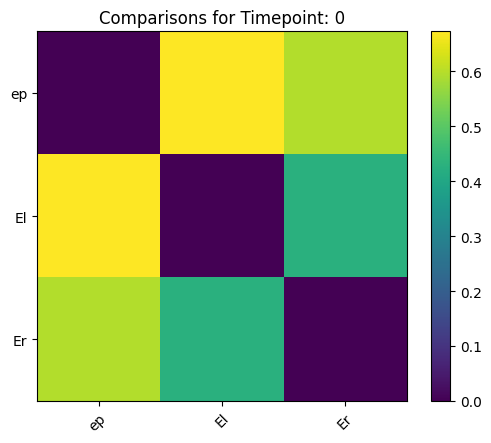

In [ ]:
plot_clustermap(file,time,normalization)